<a href="https://colab.research.google.com/github/ayyanarh1/tamil-nadu-school-flood-risk/blob/main/day4_era5_climate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Setup
!pip install cdsapi xarray netCDF4 matplotlib geopandas folium -q

import cdsapi
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium

print('✅ All libraries ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.6 MB/s eta 0:00:00
✅ All libraries ready!


In [3]:
# Configure CDS API
import os

# Create .cdsapirc config file
cds_key = "497dbf43-98f6-46cc-b8e3-95f23bd9df65"  # paste your key here

config = f"""url: https://cds.climate.copernicus.eu/api
key: {cds_key}
"""

with open(os.path.expanduser('~/.cdsapirc'), 'w') as f:
    f.write(config)

print('✅ CDS API configured!')

# Test connection
import cdsapi
c = cdsapi.Client()
print('✅ CDS connection successful!')

✅ CDS API configured!
✅ CDS connection successful!


In [6]:
# Download ERA5 monthly rainfall for Tamil Nadu
import cdsapi
import xarray as xr
import pandas as pd
import numpy as np

c = cdsapi.Client()

print('Downloading ERA5 rainfall data...')
print('This may take 2-3 minutes...')

c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': 'total_precipitation',
        'year': [
            '2018', '2019', '2020',
            '2021', '2022', '2023'
        ],
        'month': [
            '01', '02', '03', '04', '05', '06',
            '07', '08', '09', '10', '11', '12'
        ],
        'time': '00:00',
        'area': [13.5, 76.0, 8.0, 80.5],  # Tamil Nadu bbox
        'format': 'netcdf'
    },
    'tamil_nadu_rainfall.nc'
)

print('✅ ERA5 rainfall downloaded!')

This may take 2-3 minutes...


2026-03-21 20:16:51,568 INFO Request ID is 97090a71-f8c0-4e9d-9884-d2d717f650e3
INFO:ecmwf.datastores.legacy_client:Request ID is 97090a71-f8c0-4e9d-9884-d2d717f650e3
2026-03-21 20:16:51,837 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-03-21 20:17:06,035 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-03-21 20:17:13,764 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


e00096102cec4501dfb8f229cb05825.nc:   0%|          | 0.00/81.2k [00:00<?, ?B/s]

✅ ERA5 rainfall downloaded!


In [7]:
# Load and explore ERA5 rainfall data
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the downloaded file
ds = xr.open_dataset('tamil_nadu_rainfall.nc')

print('=== ERA5 Dataset Info ===')
print(ds)
print()
print('Variables:', list(ds.data_vars))
print('Dimensions:', dict(ds.dims))
print('Time range:', str(ds.time.values[0])[:10],
      'to', str(ds.time.values[-1])[:10])
print('Total months:', len(ds.time))

=== ERA5 Dataset Info ===
<xarray.Dataset> Size: 128kB
Dimensions:     (valid_time: 72, latitude: 23, longitude: 19)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 576B 2018-01-01T06:00:00 ... 2023...
  * latitude    (latitude) float64 184B 13.5 13.25 13.0 12.75 ... 8.5 8.25 8.0
  * longitude   (longitude) float64 152B 76.0 76.25 76.5 ... 80.0 80.25 80.5
    number      int64 8B ...
    expver      (valid_time) <U4 1kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 126kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-21T20:17 GRIB to CDM+CF via cfgrib-0.9.1...

Variables: ['tp']
Dimensions: {'valid_time': 72, 'latitude': 23, 'longitude': 19}


/tmp/ipykernel_707/3120657423.py:14: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Dimensions:', dict(ds.dims))


AttributeError: 'Dataset' object has no attribute 'time'

In [8]:
# 4b — Fixed with correct dimension name
import xarray as xr
import pandas as pd
import numpy as np

ds = xr.open_dataset('tamil_nadu_rainfall.nc')

print('✅ ERA5 loaded successfully!')
print('Variable: tp (total precipitation)')
print('Time range:',
      str(ds.valid_time.values[0])[:10],
      'to',
      str(ds.valid_time.values[-1])[:10])
print('Total months:', len(ds.valid_time))
print('Grid size:', ds.dims['latitude'], 'x', ds.dims['longitude'])

# Convert precipitation from metres to mm
# ERA5 monthly total = metres, multiply by 1000 for mm
tp_mm = ds['tp'] * 1000

# Calculate monthly mean rainfall across Tamil Nadu
tn_mean_rainfall = tp_mm.mean(dim=['latitude', 'longitude'])

# Convert to pandas series
rainfall_series = pd.Series(
    tn_mean_rainfall.values,
    index=pd.to_datetime(ds.valid_time.values)
)

print()
print('=== Monthly Rainfall Summary (mm) ===')
print(f'Average monthly rainfall: {rainfall_series.mean():.1f} mm')
print(f'Maximum monthly rainfall: {rainfall_series.max():.1f} mm')
print(f'Month of max rainfall:    {rainfall_series.idxmax().strftime("%B %Y")}')
print(f'Minimum monthly rainfall: {rainfall_series.min():.1f} mm')

✅ ERA5 loaded successfully!
Variable: tp (total precipitation)
Time range: 2018-01-01 to 2023-12-01
Total months: 72
Grid size: 23 x 19

=== Monthly Rainfall Summary (mm) ===
Average monthly rainfall: 3.9 mm
Maximum monthly rainfall: 15.0 mm
Month of max rainfall:    November 2021
Minimum monthly rainfall: 0.2 mm


/tmp/ipykernel_707/734180680.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Grid size:', ds.dims['latitude'], 'x', ds.dims['longitude'])


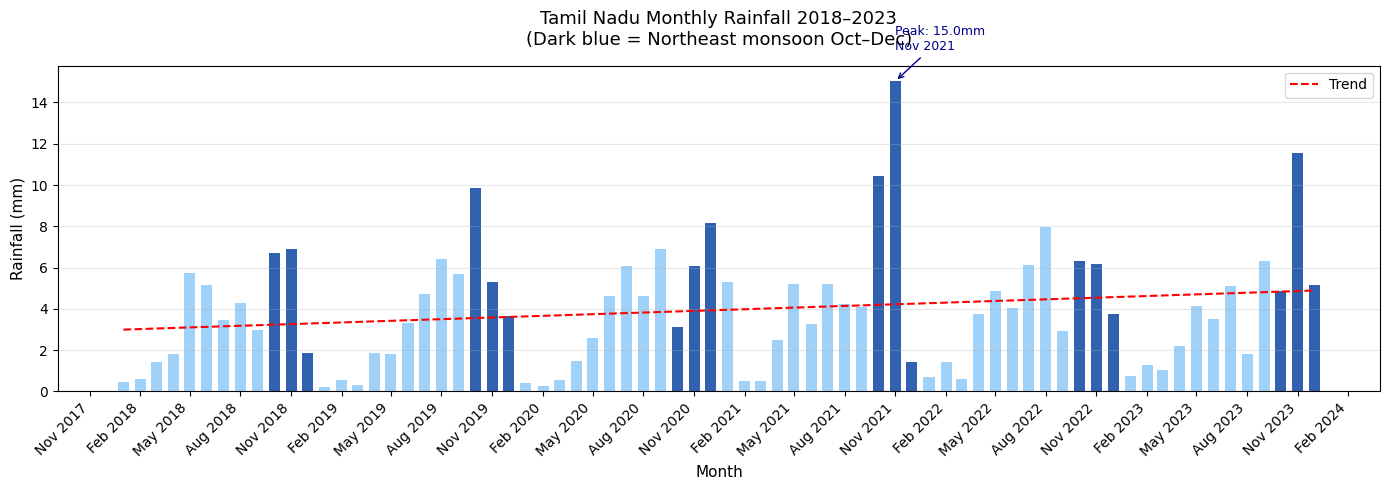

✅ Rainfall chart saved!


In [9]:
# Plot rainfall time series
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# Highlight northeast monsoon months (Oct-Dec)
fig, ax = plt.subplots(figsize=(14, 5))

# Plot rainfall bars
colors = ['#0d47a1' if m in [10, 11, 12] else '#90CAF9'
          for m in rainfall_series.index.month]

ax.bar(rainfall_series.index, rainfall_series.values,
       color=colors, width=20, alpha=0.85)

# Add trend line
z = np.polyfit(range(len(rainfall_series)), rainfall_series.values, 1)
p = np.poly1d(z)
ax.plot(rainfall_series.index,
        p(range(len(rainfall_series))),
        'r--', linewidth=1.5, label='Trend')

# Formatting
ax.set_title('Tamil Nadu Monthly Rainfall 2018–2023\n'
             '(Dark blue = Northeast monsoon Oct–Dec)',
             fontsize=13, pad=15)
ax.set_ylabel('Rainfall (mm)', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add annotation for peak
peak_date = rainfall_series.idxmax()
peak_val = rainfall_series.max()
ax.annotate(f'Peak: {peak_val:.1f}mm\n{peak_date.strftime("%b %Y")}',
            xy=(peak_date, peak_val),
            xytext=(peak_date, peak_val + 1.5),
            fontsize=9, color='darkblue',
            arrowprops=dict(arrowstyle='->', color='darkblue'))

plt.tight_layout()
plt.savefig('tamil_nadu_rainfall_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Rainfall chart saved!')

In [11]:
# Cell 6 — Extract rainfall at each school location
import xarray as xr
import pandas as pd
import numpy as np

# School coordinates
schools = {
    'Govt High School Chennai':      [13.08, 80.27],
    'Govt School Cuddalore':         [11.75, 79.75],
    'Panchayat School Nagapattinam': [10.76, 79.84],
    'Govt School Thanjavur':         [10.78, 79.13],
    'High School Coimbatore':        [11.01, 76.96],
    'Govt School Madurai':           [9.93,  78.12],
    'Panchayat School Tirunelveli':  [8.71,  77.69],
    'Govt School Salem':             [11.65, 78.16],
    'High School Vellore':           [12.92, 79.13],
    'Govt School Tiruchirappalli':   [10.79, 78.68],
    'School Ramanathapuram':         [9.37,  78.83],
    'School Puducherry Border':      [11.93, 79.83],
    'School Kanchipuram':            [12.83, 79.70],
    'School Villupuram':             [11.93, 79.49],
    'School Tuticorin':              [8.80,  78.15],
}

# Load ERA5
ds = xr.open_dataset('tamil_nadu_rainfall.nc')
tp_mm = ds['tp'] * 1000

# Extract rainfall at nearest grid point for each school
school_rainfall = {}

for name, (lat, lon) in schools.items():
    # Find nearest grid point
    school_ts = tp_mm.sel(
        latitude=lat,
        longitude=lon,
        method='nearest'
    )
    # Annual mean rainfall
    school_df = pd.Series(
        school_ts.values,
        index=pd.to_datetime(ds.valid_time.values)
    )
    school_rainfall[name] = {
        'annual_mean_mm': school_df.mean() * 12,
        'oct_dec_mean_mm': school_df[school_df.index.month.isin([10,11,12])].mean(),
        'max_month_mm': school_df.max(),
        'max_month': school_df.idxmax().strftime('%b %Y')
    }

rainfall_df = pd.DataFrame(school_rainfall).T.reset_index()
rainfall_df.columns = ['school_name', 'annual_mean_mm',
                        'oct_dec_mean_mm', 'max_month_mm', 'max_month']
rainfall_df = rainfall_df.sort_values(
    'oct_dec_mean_mm', ascending=False
).reset_index(drop=True)

# Round numbers
for col in ['annual_mean_mm', 'oct_dec_mean_mm', 'max_month_mm']:
    rainfall_df[col] = rainfall_df[col].round(1)

print('=== RAINFALL BY SCHOOL LOCATION ===')
print('(Oct-Dec = Northeast monsoon season)\n')
print(f"{'School':<35} {'Annual':>8} {'Oct-Dec':>9} {'Max month':<12}")
print('-' * 70)
for _, row in rainfall_df.iterrows():
    print(f"{row['school_name'][:34]:<35} "
          f"{row['annual_mean_mm']:>7.1f}mm "
          f"{row['oct_dec_mean_mm']:>8.1f}mm "
          f"{row['max_month']:<12}")

=== RAINFALL BY SCHOOL LOCATION ===
(Oct-Dec = Northeast monsoon season)

School                                Annual   Oct-Dec Max month   
----------------------------------------------------------------------
Panchayat School Nagapattinam          43.7mm      9.2mm Nov 2023    
Govt School Cuddalore                  39.3mm      8.1mm Nov 2021    
School Ramanathapuram                  37.2mm      7.9mm Nov 2023    
School Tuticorin                       33.2mm      7.8mm Nov 2021    
Govt High School Chennai               39.4mm      7.8mm Nov 2021    
School Puducherry Border               38.5mm      7.7mm Nov 2021    
Panchayat School Tirunelveli           38.8mm      7.4mm Nov 2021    
Govt School Thanjavur                  37.2mm      6.3mm Nov 2021    
School Kanchipuram                     37.0mm      6.2mm Nov 2021    
School Villupuram                      37.1mm      6.1mm Nov 2021    
Govt School Madurai                    34.5mm      5.8mm Nov 2023    
High School Vello

In [12]:
# Add rainfall to master risk score
import pandas as pd

# Master risk from Day 3
master_data = {
    'school_name': [
        'School Puducherry Border',
        'Panchayat School Nagapattinam',
        'School Ramanathapuram',
        'Govt School Cuddalore',
        'School Tuticorin',
        'School Kanchipuram',
        'Govt School Tiruchirappalli',
        'Panchayat School Tirunelveli',
        'Govt School Thanjavur',
        'High School Vellore',
        'School Villupuram',
        'Govt School Madurai',
        'Govt High School Chennai',
        'High School Coimbatore',
        'Govt School Salem'
    ],
    'connectivity': [
        'connected', 'none', 'none', 'none',
        'connected', 'none', 'none', 'none',
        'connected', 'connected', 'none',
        'connected', 'connected', 'connected', 'connected'
    ],
    'final_score': [
        98.2, 52.0, 38.8, 34.4, 34.0,
        29.6, 28.6, 25.2, 21.8, 18.2,
        18.1, 7.5, 6.0, 0.0, 0.0
    ],
    'final_risk': [
        'CRITICAL', 'CRITICAL', 'HIGH', 'HIGH', 'HIGH',
        'HIGH', 'HIGH', 'HIGH', 'MEDIUM', 'MEDIUM',
        'MEDIUM', 'LOW', 'LOW', 'LOW', 'LOW'
    ]
}

master_df = pd.DataFrame(master_data)

# Merge rainfall data
final_df = master_df.merge(
    rainfall_df[['school_name', 'annual_mean_mm',
                 'oct_dec_mean_mm', 'max_month']],
    on='school_name'
)

# Normalise rainfall 0-100
max_rain = final_df['oct_dec_mean_mm'].max()
final_df['rain_norm'] = (
    final_df['oct_dec_mean_mm'] / max_rain * 100
).round(1)

# Updated final score — add 10% rainfall component
final_df['updated_score'] = (
    0.90 * final_df['final_score'] +
    0.10 * final_df['rain_norm']
).round(1)

# Updated risk tier
def updated_risk(score):
    if score >= 50:
        return 'CRITICAL'
    elif score >= 25:
        return 'HIGH'
    elif score >= 10:
        return 'MEDIUM'
    else:
        return 'LOW'

final_df['updated_risk'] = final_df['updated_score'].apply(updated_risk)
final_df = final_df.sort_values(
    'updated_score', ascending=False
).reset_index(drop=True)
final_df['rank'] = final_df.index + 1

# Print final table
print('=== FINAL RISK TABLE — 4 DATA SOURCES ===')
print('SAR + JRC + GFD + ERA5 Rainfall\n')
print(f"{'#':<3} {'School':<32} {'Conn':<5} "
      f"{'Rain':>6} {'Score':>7} {'Risk'}")
print('-' * 65)
for _, row in final_df.iterrows():
    conn = 'No' if row['connectivity'] == 'none' else 'Yes'
    print(f"#{int(row['rank']):<2} "
          f"{row['school_name'][:31]:<32} "
          f"{conn:<5} "
          f"{row['oct_dec_mean_mm']:>5.1f}mm "
          f"{row['updated_score']:>6.1f} "
          f"{row['updated_risk']}")

=== FINAL RISK TABLE — 4 DATA SOURCES ===
SAR + JRC + GFD + ERA5 Rainfall

#   School                           Conn    Rain   Score Risk
-----------------------------------------------------------------
#1  School Puducherry Border         Yes     7.7mm   96.7 CRITICAL
#2  Panchayat School Nagapattinam    No      9.2mm   56.8 CRITICAL
#3  School Ramanathapuram            No      7.9mm   43.5 HIGH
#4  Govt School Cuddalore            No      8.1mm   39.8 HIGH
#5  School Tuticorin                 Yes     7.8mm   39.1 HIGH
#6  School Kanchipuram               No      6.2mm   33.3 HIGH
#7  Govt School Tiruchirappalli      No      5.2mm   31.4 HIGH
#8  Panchayat School Tirunelveli     No      7.4mm   30.7 HIGH
#9  Govt School Thanjavur            Yes     6.3mm   26.5 HIGH
#10 School Villupuram                No      6.1mm   22.9 MEDIUM
#11 High School Vellore              Yes     5.3mm   22.1 MEDIUM
#12 Govt High School Chennai         Yes     7.8mm   13.8 MEDIUM
#13 Govt School Madurai   

In [14]:
# Save all outputs
from google.colab import files
import matplotlib.pyplot as plt

# Save final risk table
final_df.to_csv('tamil_nadu_day4_final_risk.csv', index=False)
print('✅ Risk CSV saved!')

# Save rainfall chart
files.download('tamil_nadu_rainfall_timeseries.png')
files.download('tamil_nadu_day4_final_risk.csv')
print('✅ All files downloaded!')

# Print summary
print()
print('=== DAY 4 SUMMARY ===')
print(f"CRITICAL schools: {len(final_df[final_df.updated_risk == 'CRITICAL'])}")
print(f"HIGH schools:     {len(final_df[final_df.updated_risk == 'HIGH'])}")
print(f"MEDIUM schools:   {len(final_df[final_df.updated_risk == 'MEDIUM'])}")
print(f"LOW schools:      {len(final_df[final_df.updated_risk == 'LOW'])}")
print()
print('Peak monsoon month: November')
print('Highest rainfall school: Panchayat School Nagapattinam')
print('Safest schools: Coimbatore, Salem')

✅ Risk CSV saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!

=== DAY 4 SUMMARY ===
CRITICAL schools: 2
HIGH schools:     7
MEDIUM schools:   4
LOW schools:      2

Peak monsoon month: November
Highest rainfall school: Panchayat School Nagapattinam
Safest schools: Coimbatore, Salem
